firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


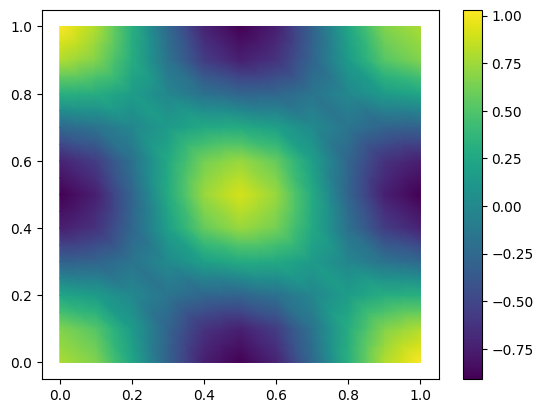

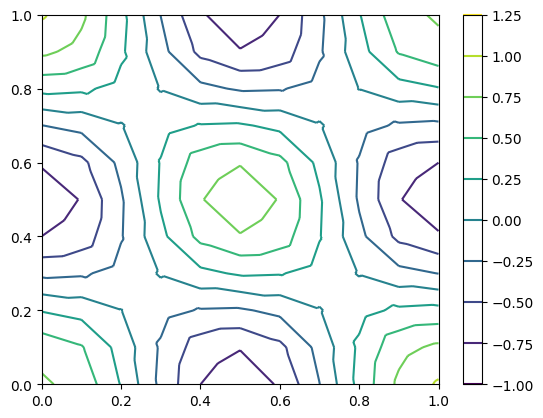

0.06257073783339019


In [1]:
from firedrake import *
mesh = UnitSquareMesh(10, 10)
# first-order polynomial/CG
V = FunctionSpace(mesh, "P", 1)
u = TrialFunction(V)
v = TestFunction(V)
f = Function(V)
x, y = SpatialCoordinate(mesh)

f.interpolate((1+8*pi*pi)*cos(x*pi*2)*cos(y*pi*2))
a = (inner(grad(u), grad(v)) + inner(u, v)) * dx
L = inner(f, v) * dx
u = Function(V)
solve(a == L, u)

import matplotlib.pyplot as plt
from firedrake.pyplot import tripcolor, tricontour
fig, axes = plt.subplots()
colors = tripcolor(u, axes=axes)
fig.colorbar(colors)
fig, axes = plt.subplots()
contours = tricontour(u, axes=axes)
fig.colorbar(contours)
plt.show()

f.interpolate(cos(x*pi*2)*cos(y*pi*2))
print(sqrt(assemble(dot(u - f, u - f) * dx)))


firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


  n       h          L2 error       rate of convergence
  10    0.100000     6.257074e-02   NaN
  20    0.050000     1.713381e-02   1.869
  30    0.033333     7.751206e-03   1.956
  40    0.025000     4.387639e-03   1.978
  50    0.020000     2.816376e-03   1.987
  60    0.016667     1.958970e-03   1.991
  70    0.014286     1.440649e-03   1.994
  80    0.012500     1.103698e-03   1.995
  90    0.011111     8.724396e-04   1.996
 100    0.010000     7.068979e-04   1.997


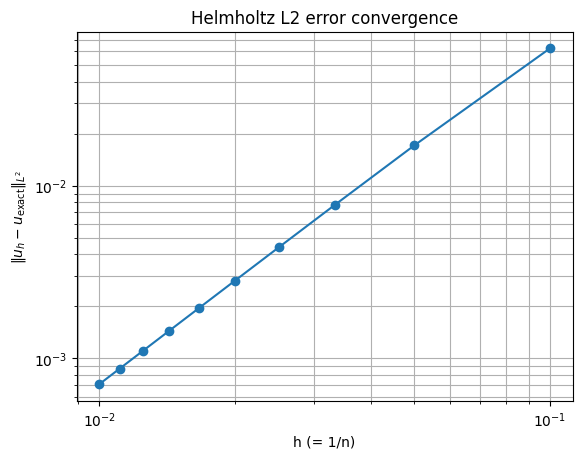

In [1]:
from firedrake import *
import matplotlib.pyplot as plt
from firedrake.pyplot import tripcolor, tricontour
import numpy as np

ns = [10,20,30,40,50,60,70,80,90,100]   # mesh refinements           
hs = []
errs = []

for n in ns:
    mesh = UnitSquareMesh(n, n)
    # first-order polynomial/CG
    V = FunctionSpace(mesh, "CG", 1)
    u = TrialFunction(V)
    v = TestFunction(V)
    x, y = SpatialCoordinate(mesh)

    # exact solution
    u_exact_expression = cos(2*pi*x) * cos(2*pi*y)

    # f
    f = Function(V)
    f.interpolate((1+8*pi*pi) * u_exact_expression)

    # Weak form
    a = (inner(grad(u), grad(v)) + inner(u,v)) * dx
    L = inner(f,v) * dx

    # Solve
    uh = Function(V)
    solve(a == L, uh)

    # comparison
    u_exact = Function(V)
    u_exact.interpolate(u_exact_expression)

    # L2 error
    err = np.sqrt(assemble((uh - u_exact)**2 * dx))

    h = 1.0 / n  # mesh size
    hs.append(h)
    errs.append(err)

print("  n       h          L2 error       rate of convergence")
for i, n in enumerate(ns):
    h = hs[i]
    e = errs[i]
    if i == 0:
        q_str = "NaN"
    else:
        q = np.log(errs[i-1]/e) / np.log(hs[i-1]/h)
        q_str = f"{q:.3f}"
    print(f"{n:4d}   {h:9.6f}   {e:14.6e}   {q_str}")

# plot
plt.figure()
plt.loglog(hs, errs, marker="o")
plt.xlabel("h (= 1/n)")
plt.ylabel(r"$\|u_h - u_{\mathrm{exact}}\|_{L^2}$")
plt.title(f"Helmholtz L2 error convergence")
plt.grid(True, which="both")
plt.show()